# Signature Verification — Siamese + Transfer Learning

Same Siamese idea as notebook 2, but the tower is now a pretrained **MobileNetV2** instead of a
CNN built from scratch. The backbone already knows useful visual features from ImageNet, so we
freeze it and just train a small embedding head on top.

**Techniques used:** transfer learning, MobileNetV2, frozen backbone, contrastive loss, EER threshold

## 1. Imports

In [23]:
import os, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Lambda
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, roc_curve

## 2. Get the Dataset

In [24]:
# clone the project repo (run once) — the dataset ships inside it
!git clone https://github.com/goyashek/Signature-forgery-verification.git

DATA_ROOT = 'Signature-forgery-verification/sign_data'
IMG_DIR   = os.path.join(DATA_ROOT, 'train')

# MobileNetV2 wants 3-channel input; we use a slightly bigger size
IMG_H, IMG_W = 160, 224

fatal: destination path 'Signature-forgery-verification' already exists and is not an empty directory.


## 3. Writer-independent split + leak-free pairing

Same data handling as notebook 2 (see `01b_data_leak_investigation.ipynb` for the full diagnosis):

1. **Duplicate test folder** → split by **writer id** (train ≤40, val 41–48, test ≥49), test only on
   unseen people.
2. **The pairing leak** → rebuild pairs from the raw folders and add *genuine-vs-different-writer*
   negatives, so a genuine `img2` no longer gives away the label and the tower must learn real
   similarity rather than a forgery-artifact shortcut.

In [25]:
# Index the raw folders (same approach as notebook 2): build pairs ourselves so we can add
# the different-writer negatives the CSV doesn't contain.
import random
from collections import defaultdict

genuine, forg = defaultdict(list), defaultdict(list)
for d in sorted(os.listdir(IMG_DIR)):
    full = os.path.join(IMG_DIR, d)
    if not os.path.isdir(full):
        continue
    files = [os.path.join(d, f) for f in os.listdir(full) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if d.endswith('_forg'):
        forg[int(d.replace('_forg', ''))].extend(files)
    else:
        genuine[int(d)].extend(files)

writers = sorted(set(genuine) & set(forg))
train_writers = [w for w in writers if w <= 40]
val_writers   = [w for w in writers if 41 <= w <= 48]
test_writers  = [w for w in writers if w >= 49]
print('writers ->', len(train_writers), 'train |', len(val_writers), 'val |', len(test_writers), 'test')

writers -> 35 train | 8 val | 21 test


## 4. Build the pairs + a streaming data generator

Label semantics: **0 = same writer (similar), 1 = non-match (different)**, where a non-match is
either a forgery of the writer or a different writer's genuine signature.

MobileNetV2 RGB inputs are memory-heavy (~430 KB per image at 160×224×3 float32), and loading every
pair into RAM at once **OOMs Colab during `fit`**. So instead of one big array, we use a
`keras.utils.Sequence` that reads and preprocesses only one batch from disk at a time. RAM stays
flat, and we can keep the full `per_writer=80`. Each batch converts to 3-channel RGB, resizes, and
runs `preprocess_input` (scales to [-1, 1]). Validation/test generators use `shuffle=False` so
`model.predict` output lines up with `labels()`.

In [26]:
import math
from keras.utils import Sequence

def make_pairs(wset, per_writer, seed=42):
    """Build balanced pairs from the folders. Three recipes:
       match (0): two genuine of the same writer
       hard negative (1): genuine vs a forgery of that writer
       random negative (1): genuine vs a *different* writer's genuine  <- kills the leak
    """
    rng = random.Random(seed)
    wlist = sorted(wset)
    rows = []
    for w in wlist:
        g = genuine.get(w, [])
        if len(g) < 2:
            continue
        for _ in range(per_writer):                       # match
            a, b = rng.sample(g, 2)
            rows.append((a, b, 0))
        for _ in range(per_writer // 2):                  # hard negative: forgery of w
            if forg.get(w):
                rows.append((rng.choice(g), rng.choice(forg[w]), 1))
        for _ in range(per_writer // 2):                  # random negative: different writer
            other = rng.choice([x for x in wlist if x != w])
            rows.append((rng.choice(g), rng.choice(genuine[other]), 1))
    rng.shuffle(rows)
    return pd.DataFrame(rows, columns=['img1', 'img2', 'label'])

class PairSequence(Sequence):
    """Streams image pairs from disk, but memoizes each decoded image (uint8) so epochs after
    the first do no disk I/O — the same few signatures per writer are reused across many pairs.
    Plenty of RAM here, so this is a big speedup over re-reading every batch. preprocess_input
    runs per batch on the cached arrays. `root` is prepended to each path (IMG_DIR for sign_data;
    '' for absolute NFI paths). Keep shuffle=False for val/test so predict stays aligned with
    labels()."""
    def __init__(self, frame, batch_size=64, shuffle=False, root=IMG_DIR, cache=None):
        # Keras 3 PyDataset takes worker args here; guard so it also works on older Sequence.
        try:
            super().__init__(workers=4, use_multiprocessing=False, max_queue_size=12)
        except TypeError:
            super().__init__()
        self.rows = frame.reset_index(drop=True)
        self.bs = batch_size
        self.shuffle = shuffle
        self.root = root
        self.cache = {} if cache is None else cache   # decoded-image memo
        self.idx = np.arange(len(self.rows))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.rows) / self.bs)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.idx)

    def _load(self, path):
        full = os.path.join(self.root, path)
        im = self.cache.get(full)
        if im is None:
            im = cv2.cvtColor(cv2.imread(full), cv2.COLOR_BGR2RGB)
            im = cv2.resize(im, (IMG_W, IMG_H))
            self.cache[full] = im                          # store decoded uint8 (~100 KB each)
        return im

    def __getitem__(self, i):
        b = self.idx[i * self.bs:(i + 1) * self.bs]
        sub = self.rows.iloc[b]
        X1 = preprocess_input(np.array([self._load(p) for p in sub['img1']], dtype='float32'))
        X2 = preprocess_input(np.array([self._load(p) for p in sub['img2']], dtype='float32'))
        y  = sub['label'].to_numpy().astype('float32')
        return (X1, X2), y   # tuple, not list: Keras 3 needs a tuple for the multi-input model

    def labels(self):
        return self.rows['label'].to_numpy()

BATCH = 64   # GPU RAM is barely used — raise to 128 if you want fewer steps/epoch
# per_writer=80 -> ~2*80 pairs per writer; decoded images are cached after epoch 1
train_gen = PairSequence(make_pairs(train_writers, per_writer=80),         batch_size=BATCH, shuffle=True)
val_gen   = PairSequence(make_pairs(val_writers,   per_writer=80, seed=1), batch_size=BATCH, shuffle=False)
test_gen  = PairSequence(make_pairs(test_writers,  per_writer=80, seed=2), batch_size=BATCH, shuffle=False)
y_va = val_gen.labels()
y_te = test_gen.labels()
print('batches -> train', len(train_gen), '| val', len(val_gen), '| test', len(test_gen))
print('train label balance:', dict(zip(*np.unique(train_gen.labels(), return_counts=True))))

batches -> train 88 | val 20 | test 53
train label balance: {np.int64(0): np.int64(2800), np.int64(1): np.int64(2800)}


## 5. Tower on a frozen MobileNetV2

Load MobileNetV2 without its top, freeze it, and add a small embedding head. Only the head trains.

In [27]:
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_H, IMG_W, 3))
base.trainable = False   # freeze the backbone

tower = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128),
], name='tower')
tower.summary()

/tmp/ipykernel_468/2947191113.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_H, IMG_W, 3))


Model: "tower"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,816 (9.99 MB)

 Trainable params: 360,832 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Assemble the Siamese model

In [28]:
def euclidean_distance(vecs):
    a, b = vecs
    return tf.sqrt(tf.reduce_sum(tf.square(a - b), axis=1, keepdims=True) + 1e-9)

input_a = Input(shape=(IMG_H, IMG_W, 3))
input_b = Input(shape=(IMG_H, IMG_W, 3))
distance = Lambda(euclidean_distance)([tower(input_a), tower(input_b)])
model = Model([input_a, input_b], distance)

## 7. Contrastive loss & training

In [29]:
def contrastive_loss(y_true, d):
    margin = 1.0
    y_true = tf.cast(y_true, tf.float32)
    return tf.reduce_mean((1 - y_true) * tf.square(d) +
                          y_true * tf.square(tf.maximum(margin - d, 0)))

model.compile(optimizer=Adam(1e-3), loss=contrastive_loss)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# generators stream batches from disk, so RAM stays flat (no giant X arrays)
history = model.fit(train_gen,
                    validation_data=val_gen,
                    epochs=20,
                    callbacks=[early_stop, reduce_lr])

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 312ms/step - loss: 1.5046 - val_loss: 0.2057 - learning_rate: 0.0010
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.2296 - val_loss: 0.1817 - learning_rate: 0.0010
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - loss: 0.2093 - val_loss: 0.1892 - learning_rate: 0.0010
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.1917 - val_loss: 0.1766 - learning_rate: 0.0010
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.1860 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.1798 - val_loss: 0.1929 - learning_rate: 0.0010
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1803
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - loss: 0.1788 - val_loss: 0.1757 - learning_rate: 0.0010
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.1729 - val_loss: 0.1801 - le

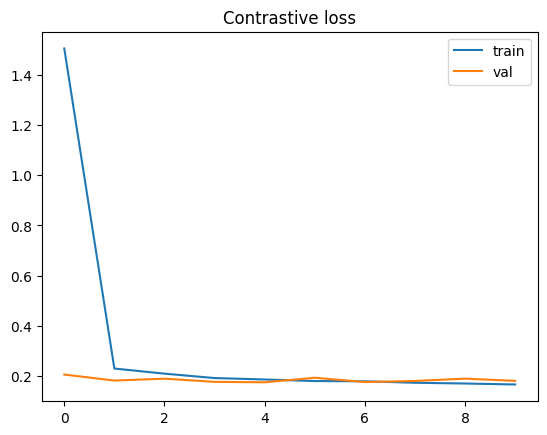

In [30]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Contrastive loss'); plt.legend(); plt.show()

## 8. Threshold (EER on validation)

In [31]:
val_d = model.predict(val_gen, verbose=0).ravel()   # aligned with y_va (val_gen shuffle=False)
fpr, tpr, thr = roc_curve(y_va, val_d)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
threshold = thr[eer_idx]
print('threshold:', round(float(threshold), 4))
print('val EER:  ', round(float((fpr[eer_idx] + fnr[eer_idx]) / 2) * 100, 2), '%')

threshold: 0.3079
val EER:   22.34 %


## 9. Evaluate on unseen writers

In [32]:
test_d = model.predict(test_gen, verbose=0).ravel()   # aligned with y_te (test_gen shuffle=False)
pred = (test_d > threshold).astype(int)

acc = (pred == y_te).mean()
auc = roc_auc_score(y_te, test_d)
far = (test_d[y_te == 1] < threshold).mean()
frr = (test_d[y_te == 0] > threshold).mean()

print('Accuracy:', round(acc * 100, 2), '%')
print('ROC-AUC :', round(auc, 3))
print('FAR     :', round(far * 100, 2), '%')
print('FRR     :', round(frr * 100, 2), '%')

Accuracy: 75.6 %
ROC-AUC : 0.829
FAR     : 20.89 %
FRR     : 27.92 %


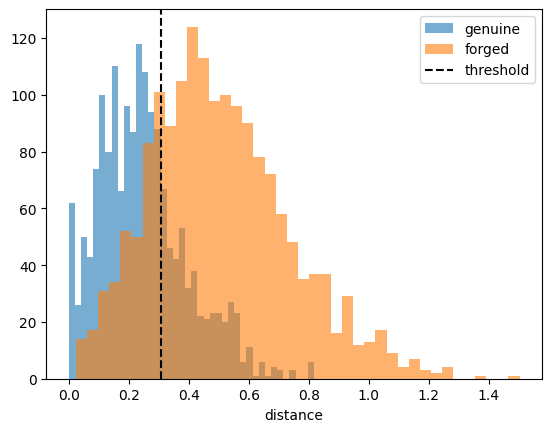

In [33]:
plt.hist(test_d[y_te == 0], bins=40, alpha=0.6, label='genuine')
plt.hist(test_d[y_te == 1], bins=40, alpha=0.6, label='forged')
plt.axvline(threshold, color='k', ls='--', label='threshold')
plt.xlabel('distance'); plt.legend(); plt.show()

## 10. Save the tower + threshold

In [34]:
tower.save('siamese_transfer_embedding.keras')
json.dump({'threshold': float(threshold), 'img_h': IMG_H, 'img_w': IMG_W,
           'preprocess': 'mobilenet_v2', 'model': 'siamese_transfer'},
          open('siamese_transfer_meta.json', 'w'))
print('saved tower + meta')

saved tower + meta


## 11. Cross-dataset test — does it hold up on a *different* dataset?

The real test of transfer learning here: take the tower we just trained on `sign_data` and evaluate
it, untouched, on the independent **NFI set** (`sign_data_nfi` — different source, targeted forgeries;
see `01b`). Transfer-learned features should travel across datasets better than a from-scratch tower,
so this is where notebook 3 can earn its keep.

We report **ROC-AUC** (threshold-free headline), the **EER if recalibrated on NFI**, and the metrics
you get by **transferring the sign_data threshold unchanged** — the realistic deployment number.

In [35]:
import glob, re

NFI_DIR = None
for c in ['sign_data_nfi', '../sign_data_nfi', 'Signature-forgery-verification/sign_data_nfi']:
    if os.path.isdir(c):
        NFI_DIR = c; break

if NFI_DIR is None:
    print('sign_data_nfi not found — skipping cross-dataset test.')
else:
    def _parse(fn):                       # NFI-XXXYYZZZ -> (signer, owner); genuine iff signer==owner
        s = re.sub(r'^NFI-', '', os.path.basename(fn)); s = os.path.splitext(s)[0]
        return (s[:3], s[5:8]) if re.fullmatch(r'\d{8}', s) else None

    nfi_gen, nfi_forg = defaultdict(list), defaultdict(list)
    for f in glob.glob(os.path.join(NFI_DIR, 'genuine', '*')):
        p = _parse(f); nfi_gen[p[1]].append(f) if p else None
    for f in glob.glob(os.path.join(NFI_DIR, 'forged', '*')):
        p = _parse(f); nfi_forg[p[1]].append(f) if p else None
    nfi_owners = sorted(set(nfi_gen) & set(nfi_forg), key=int)

    def make_nfi_pairs(per_owner=40, seed=7):
        rng = random.Random(seed); rows = []
        for o in nfi_owners:
            g = nfi_gen[o]
            if len(g) < 2:
                continue
            for _ in range(per_owner):                      # match
                a, b = rng.sample(g, 2); rows.append((a, b, 0))
            for _ in range(per_owner // 2):                 # hard negative: forgery of o
                if nfi_forg.get(o):
                    rows.append((rng.choice(g), rng.choice(nfi_forg[o]), 1))
            for _ in range(per_owner // 2):                 # random negative: different owner
                other = rng.choice([x for x in nfi_owners if x != o])
                rows.append((rng.choice(g), rng.choice(nfi_gen[other]), 1))
        rng.shuffle(rows)
        return pd.DataFrame(rows, columns=['img1', 'img2', 'label'])

    # NFI glob paths are already complete -> root='' ; shuffle=False keeps predict aligned
    nfi_df  = make_nfi_pairs()
    nfi_gen_seq = PairSequence(nfi_df, batch_size=BATCH, shuffle=False, root='')
    ny = nfi_gen_seq.labels()
    print('NFI:', len(nfi_owners), 'owners |', len(nfi_df), 'pairs |',
          'balance', dict(zip(*np.unique(ny, return_counts=True))))

    nd = model.predict(nfi_gen_seq, verbose=0).ravel()    # distance, aligned with ny

    nauc = roc_auc_score(ny, nd)
    fpr, tpr, thr = roc_curve(ny, nd); fnr = 1 - tpr
    i = np.nanargmin(np.abs(fpr - fnr)); nfi_eer = (fpr[i] + fnr[i]) / 2

    pred = (nd > threshold).astype(int)
    acc = (pred == ny).mean()
    far = (nd[ny == 1] < threshold).mean(); frr = (nd[ny == 0] > threshold).mean()

    print('\n--- cross-dataset (trained on sign_data, tested on NFI) ---')
    print('ROC-AUC                 :', round(nauc, 3))
    print('EER (recalibrated on NFI):', round(nfi_eer * 100, 2), '%')
    print('at sign_data threshold  -> acc', round(acc*100,2), '% | FAR', round(far*100,2), '% | FRR', round(frr*100,2), '%')

NFI: 30 owners | 2400 pairs | balance {np.int64(0): np.int64(1200), np.int64(1): np.int64(1200)}

--- cross-dataset (trained on sign_data, tested on NFI) ---
ROC-AUC                 : 0.713
EER (recalibrated on NFI): 34.21 %
at sign_data threshold  -> acc 67.62 % | FAR 42.25 % | FRR 22.5 %


## 12. Takeaways

- Transfer learning gives the tower a big head start — pretrained ImageNet features usually beat
  a from-scratch CNN on this much data, with less training.
- We froze the whole backbone here. A natural next step is to unfreeze the top few layers and
  fine-tune with a very small learning rate (keeping BatchNorm frozen) to squeeze out a bit more.
- MobileNetV2 is light, so this model is also easy to deploy in the Streamlit app.
- Memory note: this notebook streams batches from disk via a `keras.utils.Sequence` instead of
  loading every pair into RAM — that's what keeps it from OOMing on Colab with RGB inputs.

### Comparing all three notebooks

| Notebook | Approach | Honest generalization to unseen writers? |
|----------|----------|-------------------------------------------|
| 1 | Plain CNN on stacked pairs | **misleading** — scores 0.999 by exploiting the pairing leak (see 01b), not by comparing signatures |
| 2 | Siamese CNN (from scratch) | yes — leak-free pairs force a real distance metric |
| 3 | Siamese + MobileNetV2 | yes, usually best |

Two data lessons mattered more than the architecture:

1. The shipped `test/` folder was a copy of `train/`, so we switched to a **writer-independent
   split** — test only on people the model never saw.
2. The shipped pairing made the label a giveaway of which folder `img2` came from (the
   **pairing leak**, diagnosed in `01b_data_leak_investigation.ipynb`). Notebooks 2 and 3 rebuild
   pairs with genuine-vs-different-writer negatives so the model is forced to learn similarity.

Together these are why notebook 1's 0.999 looks better than the Siamese numbers but means less.